In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from pathlib import Path
import matplotlib.pyplot as plt
import shutil

DATA_DIR = Path("../data/raw").resolve()
print("Torch:", torch.__version__)
print("DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

Torch: 2.14.1+cu130
DATA_DIR: /home/student/project/foodlens/data/raw
Exists: True


In [2]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))
print("Class mapping:", full_dataset.class_to_idx)

Classes: ['egusi_soup', 'jollof_rice']
Total images: 44
Class mapping: {'egusi_soup': 0, 'jollof_rice': 1}


In [3]:
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms ready")

Transforms ready


In [4]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_tf)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train: 36, Val: 8
Train batches: 5, Val batches: 1


In [5]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(full_dataset.classes)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model ready. Classes: {num_classes}. Device: {device}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:31<00:00, 450kB/s]

Model ready. Classes: 2. Device: cpu


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

EPOCHS = 15
train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.2%}")

Epoch  1/15 | train_loss=0.6839 | val_loss=0.6447 | val_acc=75.00%
Epoch  2/15 | train_loss=0.5810 | val_loss=0.7608 | val_acc=37.50%
Epoch  3/15 | train_loss=0.6136 | val_loss=0.7436 | val_acc=37.50%
Epoch  4/15 | train_loss=0.5510 | val_loss=0.7087 | val_acc=62.50%
Epoch  5/15 | train_loss=0.5460 | val_loss=0.6434 | val_acc=75.00%
Epoch  6/15 | train_loss=0.4839 | val_loss=0.5829 | val_acc=87.50%
Epoch  7/15 | train_loss=0.4058 | val_loss=0.5207 | val_acc=75.00%
Epoch  8/15 | train_loss=0.4541 | val_loss=0.6176 | val_acc=62.50%
Epoch  9/15 | train_loss=0.3772 | val_loss=0.5916 | val_acc=62.50%
Epoch 10/15 | train_loss=0.3358 | val_loss=0.5395 | val_acc=87.50%
Epoch 11/15 | train_loss=0.3561 | val_loss=0.5258 | val_acc=75.00%
Epoch 12/15 | train_loss=0.2888 | val_loss=0.4820 | val_acc=75.00%
Epoch 13/15 | train_loss=0.4002 | val_loss=0.4778 | val_acc=75.00%
Epoch 14/15 | train_loss=0.4194 | val_loss=0.4321 | val_acc=87.50%
Epoch 15/15 | train_loss=0.3878 | val_loss=0.5226 | val_acc=87

In [7]:
MODEL_PATH = Path("../models/foodlens_v1.pt")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state": model.state_dict(),
    "classes": full_dataset.classes,
    "arch": "mobilenet_v2",
}, MODEL_PATH)

print(f"Saved to {MODEL_PATH}")
print(f"Classes: {full_dataset.classes}")

Saved to ../models/foodlens_v1.pt
Classes: ['egusi_soup', 'jollof_rice']


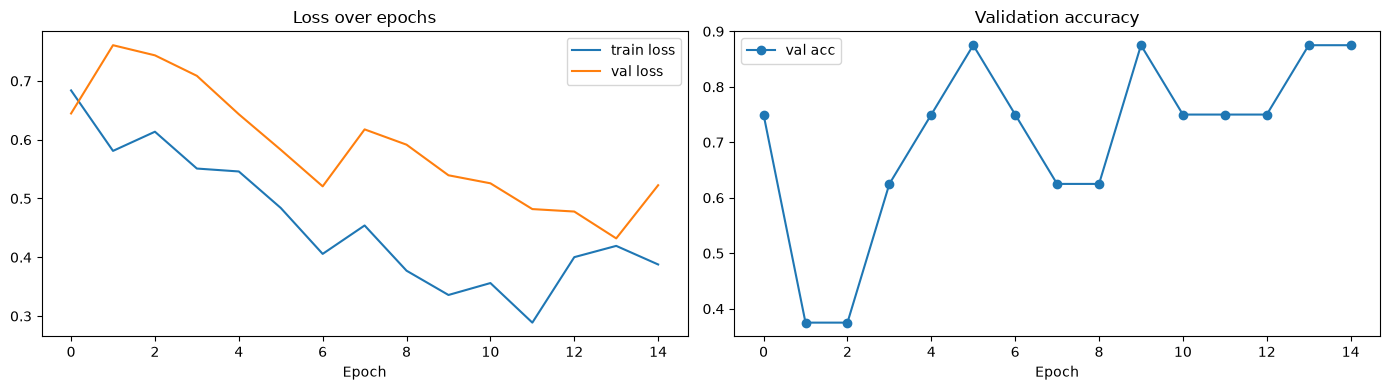

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(train_losses, label="train loss")
ax1.plot(val_losses, label="val loss")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(val_accs, marker="o", label="val acc")
ax2.set_title("Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.show()

In [9]:
from PIL import Image

def predict(image_path):
    img = Image.open(image_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_class = full_dataset.classes[pred_idx]
        confidence = probs[pred_idx].item()
    return pred_class, confidence

# Test on a jollof photo
test_img = DATA_DIR / "jollof_rice" / "jollof_001.jpg"
cls, conf = predict(test_img)
print(f"Image: {test_img.name}")
print(f"Prediction: {cls} ({conf:.2%})")

# Test on an egusi photo
test_img2 = DATA_DIR / "egusi_soup" / "egusi_001.jpg"
cls2, conf2 = predict(test_img2)
print(f"Image: {test_img2.name}")
print(f"Prediction: {cls2} ({conf2:.2%})")

[W1007 13:50:32.795960578 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.831741063 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.847155953 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.897181683 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.002509806 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.079225502 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.102908728 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:32.134445939 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.218329900 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.291333005 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Image: jollof_001.jpg
Prediction: jollof_rice (87.91%)
Image: egusi_001.jpg
Prediction: jollof_rice (61.14%)


[W1007 13:50:33.591914255 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.602414520 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.614426398 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.621765017 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.634683147 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.660103067 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.709308208 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.744190141 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.756613159 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 13:50:33.764365688 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from pathlib import Path

DATA_DIR = Path("../data/raw").resolve()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset + split
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_tf)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

# Compute class weights from training set (handles imbalance)
train_labels = [full_dataset[i][1] for i in train_ds.indices]
class_counts = torch.bincount(torch.tensor(train_labels))
class_weights = 1.0 / class_counts.float()
class_weights = class_weights / class_weights.sum() * len(class_counts)
print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.tolist())

# Model
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
model.classifier[1] = nn.Linear(model.last_channel, 2)
model = model.to(device)

# Loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0005)

# Train
EPOCHS = 20
train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.2%}")

Classes: ['egusi_soup', 'jollof_rice']
Total images: 72
Train: 58, Val: 14
Class counts: [38, 20]
Class weights: [0.6896551847457886, 1.3103448152542114]
Epoch  1/20 | train_loss=0.6864 | val_loss=0.6467 | val_acc=57.14%
Epoch  2/20 | train_loss=0.6456 | val_loss=0.6473 | val_acc=71.43%
Epoch  3/20 | train_loss=0.5679 | val_loss=0.5920 | val_acc=85.71%
Epoch  4/20 | train_loss=0.5817 | val_loss=0.5846 | val_acc=78.57%
Epoch  5/20 | train_loss=0.5323 | val_loss=0.6149 | val_acc=71.43%
Epoch  6/20 | train_loss=0.4677 | val_loss=0.5726 | val_acc=78.57%
Epoch  7/20 | train_loss=0.5001 | val_loss=0.5573 | val_acc=78.57%
Epoch  8/20 | train_loss=0.4816 | val_loss=0.5167 | val_acc=78.57%
Epoch  9/20 | train_loss=0.4010 | val_loss=0.5481 | val_acc=71.43%
Epoch 10/20 | train_loss=0.3965 | val_loss=0.5004 | val_acc=85.71%
Epoch 11/20 | train_loss=0.4120 | val_loss=0.5237 | val_acc=78.57%
Epoch 12/20 | train_loss=0.3657 | val_loss=0.5205 | val_acc=78.57%
Epoch 13/20 | train_loss=0.3649 | val_loss

In [3]:
from PIL import Image
import torch

simple_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict(image_path):
    img = Image.open(image_path).convert("RGB")
    tensor = simple_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        idx = probs.argmax().item()
    return full_dataset.classes[idx], probs[idx].item()

# Test 3 jollof + 3 egusi
print("--- JOLLOF ---")
for f in sorted((DATA_DIR / "jollof_rice").glob("*"))[:3]:
    cls, conf = predict(f)
    print(f"{f.name} → {cls} ({conf:.2%})")

print("--- EGUSI ---")
for f in sorted((DATA_DIR / "egusi_soup").glob("*"))[:3]:
    cls, conf = predict(f)
    print(f"{f.name} → {cls} ({conf:.2%})")

--- JOLLOF ---
jollof_001.jpg → jollof_rice (83.87%)


[W1007 14:14:44.265392369 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.273018235 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.280676044 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.308273194 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.314918455 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.328631594 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.338333061 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.343457389 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.355392867 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.363282681 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


jollof_002.jpg → jollof_rice (79.70%)
jollof_003.jpg → jollof_rice (77.95%)
--- EGUSI ---


[W1007 14:14:44.840019362 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.845662114 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.861402924 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.865362141 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.876372713 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.883903932 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.889231171 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.899962070 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.907503905 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:44.913919415 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


egusi_001.jpeg → egusi_soup (73.60%)
egusi_001.jpg → jollof_rice (69.09%)


[W1007 14:14:44.053383896 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.175520744 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.181025855 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.187626804 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.194580424 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.208796383 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.222076053 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.242204596 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.256246491 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


egusi_002.jpeg → egusi_soup (83.23%)


[W1007 14:14:45.263966451 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.281425935 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1007 14:14:45.293882536 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


In [ ]:
MODEL_PATH = Path("../models/foodlens_v2.pt")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state": model.state_dict(),
    "classes": full_dataset.classes,
    "arch": "mobilenet_v2",
    "best_val_acc": max(val_accs),
}, MODEL_PATH)

print(f"✅ Saved to {MODEL_PATH}")
print(f"Best validation accuracy: {max(val_accs):.2%}")